# Probabilistic Modeling Approach #
In the following varying probabilistic models are being tested on the given data. First a rudamentary supervised learning approach is applied to the data selecting **Latitude** and **Longitude** as predictors for **RSRP**, **PUSCH Rate** and **PUSCH MCS**. It is being implemented using the frequentist view on the problem. We will minimize the mean squared error of the target features. 

In [1]:
import torch

import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [2]:
import pandas as pd


data = pd.read_csv('../data/normalized_data.csv')

n_pci = 1008
embedding_dim = 1

pci_embedding = nn.Embedding(n_pci, embedding_dim)

# Example batch of PCI values
pci_batch = torch.tensor(data['pci'].values, dtype=torch.long)
embedded = pci_embedding(pci_batch)

data['pci_embedding'] = embedded.detach().numpy()
data.describe()

X = data[['lat_meannorm', 'lon_meannorm', 'distance_meannorm', 'pci_embedding']].values
y = data['rsrp_meannorm'].values

X_train, X_test = X[:int(0.8 * len(X))], X[int(0.8 * len(X)):]
y_train, y_test = y[:int(0.8 * len(y))], y[int(0.8 * len(y)):]

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

X_train shape: (7000, 4), y_train shape: (7000,)
X_test shape: (1751, 4), y_test shape: (1751,)


The evaluation shows that the predictions are completely off since they predicted always the same values for all three target features. Reasons may be that the model is not sensitive enough to capture the small changes in coordinates due to lack of size or wrong biases. In the following approach, the features are going to be mapped between 0 and 1. This is spacing out the predictors **latitude** and **longitude**. With this change, the model does not need to be as sensitive to the small value variances at the cost of not being applicable to a wider area.

Epoch 1/30000, Loss: 0.9502, test loss: 0.6347
Epoch 2/30000, Loss: 0.7383, test loss: 0.8175
Epoch 3/30000, Loss: 0.6278, test loss: 0.7841
Epoch 4/30000, Loss: 0.5498, test loss: 0.6571
Epoch 5/30000, Loss: 0.5145, test loss: 0.6227
Epoch 6/30000, Loss: 0.4892, test loss: 0.5584
Epoch 7/30000, Loss: 0.4644, test loss: 0.6325
Epoch 8/30000, Loss: 0.4400, test loss: 0.8152
Epoch 9/30000, Loss: 0.4179, test loss: 0.7020
Epoch 10/30000, Loss: 0.3961, test loss: 0.7090
Epoch 11/30000, Loss: 0.3766, test loss: 0.8704
Epoch 12/30000, Loss: 0.3614, test loss: 1.0972
Epoch 13/30000, Loss: 0.3529, test loss: 1.3822
Epoch 14/30000, Loss: 0.3392, test loss: 1.6437
Epoch 15/30000, Loss: 0.3304, test loss: 1.6688
Epoch 16/30000, Loss: 0.3232, test loss: 1.8378
Epoch 17/30000, Loss: 0.3155, test loss: 1.9459
Epoch 18/30000, Loss: 0.3134, test loss: 2.6098
Epoch 19/30000, Loss: 0.3089, test loss: 3.1102
Epoch 20/30000, Loss: 0.3091, test loss: 3.1912
Epoch 21/30000, Loss: 0.3050, test loss: 3.6599
E

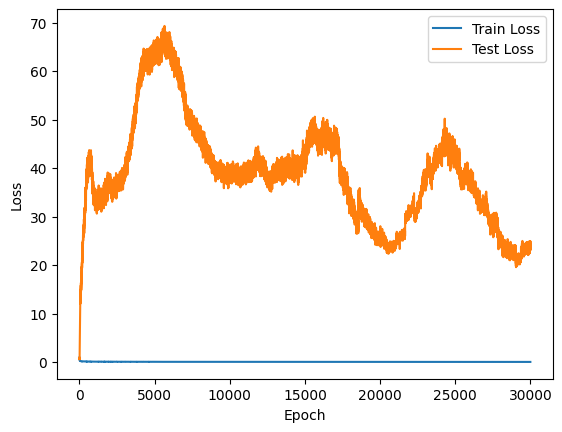

11.375016212463379


In [3]:
from torch.utils.data import TensorDataset, DataLoader


class DNN(nn.Module):
    def __init__(self):
        super(DNN, self).__init__()
        self.fc1 = nn.Linear(4, 256)
        self.fc2 = nn.Linear(256, 256)
        self.fc3 = nn.Linear(256, 128)
        self.fc4 = nn.Linear(128, 1)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.relu(self.fc3(x))
        x = self.fc4(x)
        return x

model = DNN().to(device)

batch_size = 2048

train_dataset = TensorDataset(torch.tensor(X_train, dtype=torch.float32).to(device), torch.tensor(y_train, dtype=torch.float32).to(device))
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

best_test_loss = float('inf')
best_model_state = None

best_train_loss = float('inf')
best_train_model_state = None

train_losses = []
test_losses = []

epochs = 30000
for epoch in range(epochs):
    model.train()
    epoch_loss = 0.0
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_X)
        criterion = nn.MSELoss()
        loss = criterion(outputs.squeeze(), batch_y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * batch_X.size(0)
    avg_loss = epoch_loss / len(train_loader.dataset)
    test_outputs = model(torch.tensor(X_test, dtype=torch.float32).to(device))
    test_loss = criterion(test_outputs.squeeze(), torch.tensor(y_test, dtype=torch.float32).to(device)).item()
    train_losses.append(avg_loss)
    test_losses.append(test_loss)
    if test_loss < best_test_loss and epoch > 50:
        best_test_loss = test_loss
        best_model_state = model.state_dict()
    print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}, test loss: {test_loss:.4f}")

import matplotlib.pyplot as plt
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

if best_model_state is not None:
    print(best_test_loss)
    model.load_state_dict(best_model_state)


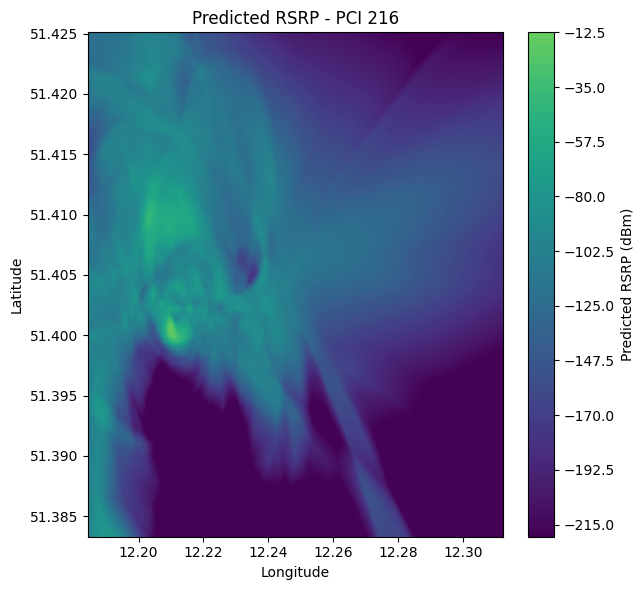

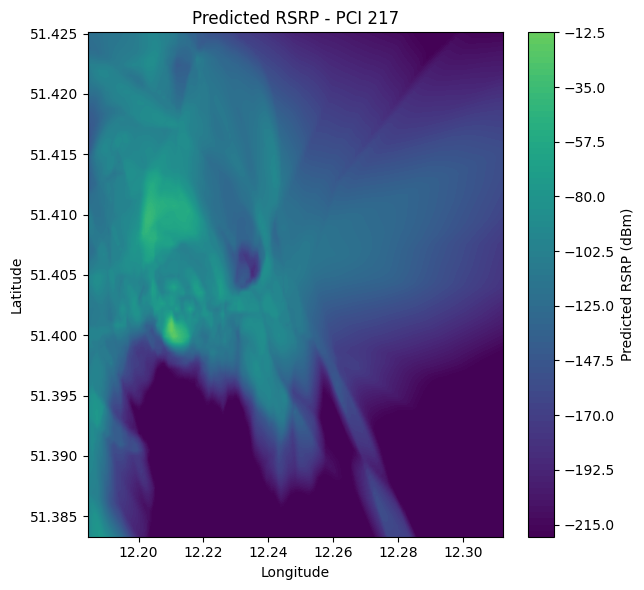

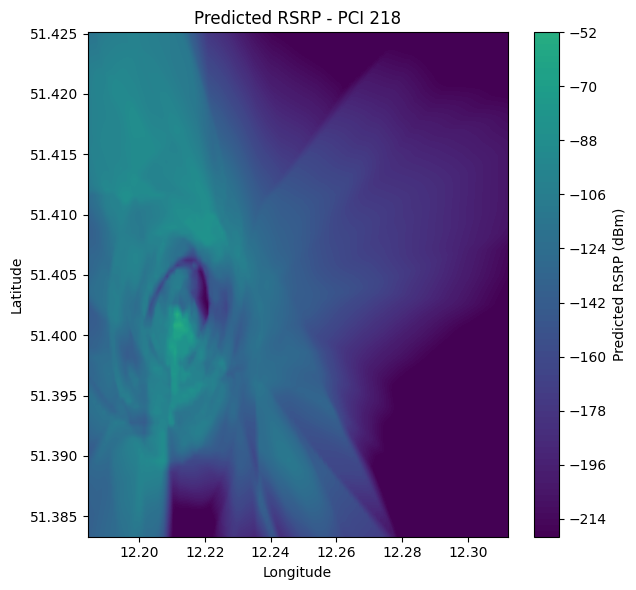

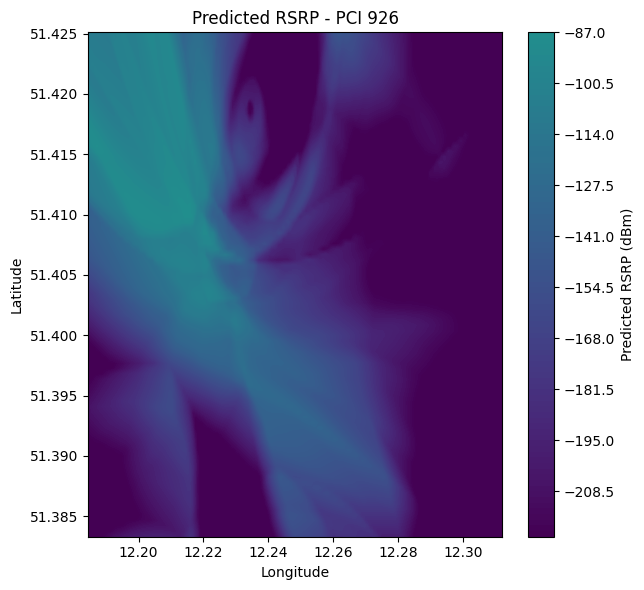

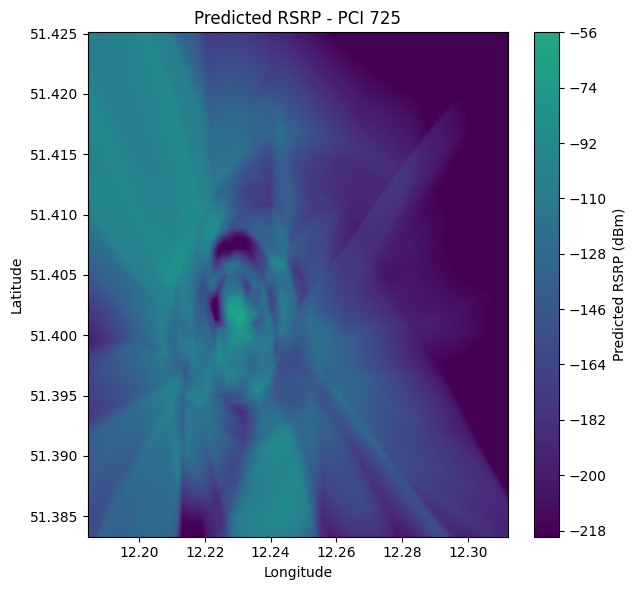

Saved predictions and input features to ../data/predicted_rsrp_conventional.csv


In [4]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from pyproj import Geod
import os
import pandas as pd

celltowerData = [
    {
        'lat': 51.401703,
        'lon': 12.211532,
        'pci_angles': [
            {
                'pci': 216
            },
            {
                'pci': 217
            },
            {
                'pci': 218
            }
        ]
    },
    {
        'lat': 51.418999, 
        'lon': 12.234410,
        'pci_angles': [
            {
                'pci': 926
            }
        ]

    },
    {
        'lat': 51.402023, 
        'lon': 12.230574,
        'pci_angles': [
            {
                'pci': 725
            }
        ]
    }
]

# Mean and std values for normalization
lat_mean, lat_std = data["lat"].mean(), data["lat"].std()
lon_mean, lon_std = data["lon"].mean(), data["lon"].std()
dist_mean, dist_std = data["distance"].mean(), data["distance"].std()
rsrp_mean, rsrp_std = data["rsrp"].mean(), data["rsrp"].std()


geod = Geod(ellps='WGS84')
spacing_m = 50

# Compute bounding box from your training data
lat_min, lat_max = np.min(data["lat"]), np.max(data["lat"])
lon_min, lon_max = np.min(data["lon"]), np.max(data["lon"])

# Prepare base lat/lon grid
lat_points = [lat_min]
while lat_points[-1] < lat_max:
    fwd = geod.fwd(lon_min, lat_points[-1], 0, spacing_m)
    lat_points.append(fwd[1])
lat_points = np.array(lat_points)

lon_points = [lon_min]
while lon_points[-1] < lon_max:
    fwd = geod.fwd(lon_points[-1], lat_min, 90, spacing_m)
    lon_points.append(fwd[0])
lon_points = np.array(lon_points)

mesh_lat, mesh_lon = np.meshgrid(lat_points, lon_points, indexing='ij')
grid_lat = mesh_lat.ravel()
grid_lon = mesh_lon.ravel()

# Loop over all PCIs in celltowerData
all_results = []

for bs in celltowerData:
    bs_lat = bs['lat']
    bs_lon = bs['lon']
    
    for pci_entry in bs['pci_angles']:
        pci_value = pci_entry['pci']

        # Distance from grid points to base station
        _, _, distances = geod.inv(
            np.full_like(grid_lon, bs_lon),
            np.full_like(grid_lat, bs_lat),
            grid_lon,
            grid_lat
        )

        # Normalize lat/lon/dist for model input only
        lat_meannorm = (grid_lat - lat_mean) / lat_std
        lon_meannorm = (grid_lon - lon_mean) / lon_std
        dist_meannorm = (distances - dist_mean) / dist_std

        # PCI embedding instead of normalization
        pci_tensor = torch.tensor([pci_value] * len(grid_lat), dtype=torch.long)
        pci_emb = pci_embedding(pci_tensor)

        # Stack input features
        numeric_features = torch.tensor(
            np.stack([lat_meannorm, lon_meannorm, dist_meannorm], axis=1),
            dtype=torch.float32
        )

        # Concatenate numeric features with PCI embedding
        input_tensor = torch.cat([numeric_features, pci_emb], dim=1).to(device)

        # Predict
        model.eval()
        with torch.no_grad():
            rsrp_meannorm_list = []
            batch_size = 64
            num_points = input_tensor.shape[0]
            for start in range(0, num_points, batch_size):
                end = start + batch_size
                batch = input_tensor[start:end]
                rsrp_meannorm_batch = model(batch)
                rsrp_meannorm_list.append(rsrp_meannorm_batch)
            rsrp_meannorm = torch.cat(rsrp_meannorm_list, dim=0)

        # Reverse normalization for RSRP
        rsrp_pred = rsrp_meannorm * rsrp_std + rsrp_mean

        # Save only original input and predicted data for this PCI
        pci_results = {
            "lat": grid_lat,
            "lon": grid_lon,
            "distance": distances,
            "pci": [pci_value] * len(grid_lat),
            "mean_rsrp": rsrp_pred.cpu().numpy().flatten(),
        }
        all_results.append(pci_results)

        # Plot
        rsrp_grid = rsrp_pred.reshape(mesh_lat.shape)
        plt.figure(figsize=(12, 6))

        # RSRP plot
        plt.subplot(1, 2, 1)
        vmin, vmax = -220, 50  # Cap color scheme
        rsrp_grid_np = rsrp_grid.cpu().numpy()
        rsrp_grid_np = np.clip(rsrp_grid_np, vmin, vmax)  # Clip values
        cf = plt.contourf(mesh_lon, mesh_lat, rsrp_grid_np, levels=100, vmin=vmin, vmax=vmax)
        plt.colorbar(cf, label="Predicted RSRP (dBm)")
        plt.title(f"Predicted RSRP - PCI {pci_value}")
        plt.xlabel("Longitude")
        plt.ylabel("Latitude")

        plt.tight_layout()
        plt.show()

# Combine all results into a single DataFrame
df_list = []
for res in all_results:
    df = pd.DataFrame(res)
    df_list.append(df)
full_pred_df = pd.concat(df_list, ignore_index=True)

# Ensure the directory exists
os.makedirs('../data', exist_ok=True)

# Save to CSV
full_pred_df.to_csv('../data/predicted_rsrp_conventional.csv', index=False)
print("Saved predictions and input features to ../data/predicted_rsrp_conventional.csv")
